<a href="https://colab.research.google.com/github/Tarakk/CML7211_ML4Chem/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Variational Auto-Encoder

In [1]:
!pip install torch scikit-learn matplotlib

torch.Size([150, 4]) torch.Size([150])


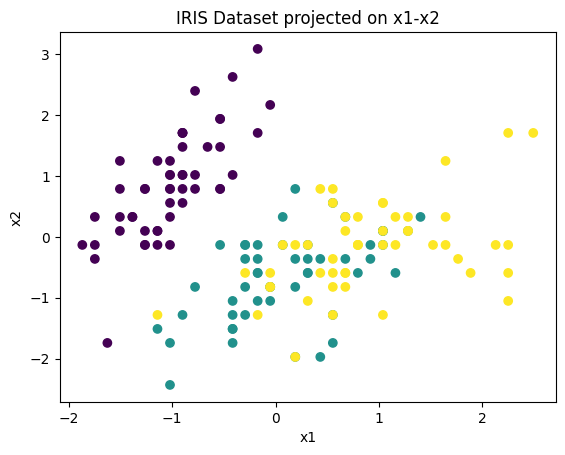

In [35]:
import torch
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Normalize (IMPORTANT for VAE)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y)

print(X.shape, y.shape)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("IRIS Dataset projected on x1-x2")
#plt.legend()
plt.show()


In [14]:
import torch.nn as nn

latent_dim = 2

class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(4, 16)
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 16)
        self.fc3 = nn.Linear(16, 4)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return self.fc3(h)  # no sigmoid (continuous data)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [17]:
def loss_function(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_loss

Epoch 0: Train 1.14, Val 1.18
Epoch 1000: Train 0.96, Val 0.83
Epoch 2000: Train 0.82, Val 0.84
Epoch 3000: Train 0.83, Val 0.77
Epoch 4000: Train 0.77, Val 0.78
Epoch 5000: Train 0.78, Val 0.76
Epoch 6000: Train 0.73, Val 0.84
Epoch 7000: Train 0.68, Val 0.80
Epoch 8000: Train 0.69, Val 0.70
Epoch 9000: Train 0.81, Val 0.71


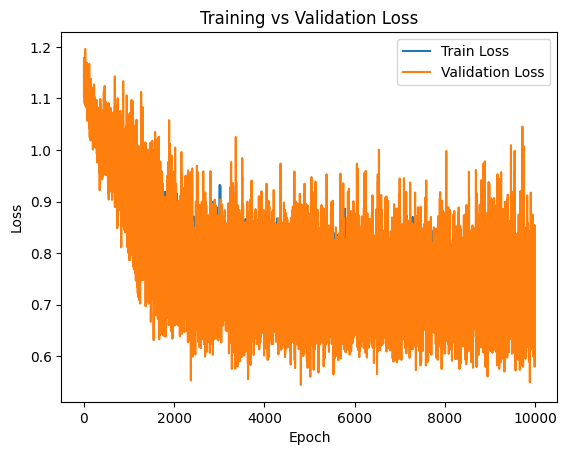

In [37]:
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Split data
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

train_losses = []
val_losses = []

model = VAE()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(10000):

    # Training
    model.train()
    optimizer.zero_grad()

    recon, mu, logvar = model(X_train)
    train_loss = loss_function(recon, X_train, mu, logvar)

    train_loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        recon, mu, logvar = model(X_val)
        val_loss = loss_function(recon, X_val, mu, logvar)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Train {train_loss.item():.2f}, Val {val_loss.item():.2f}")

plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [38]:
with torch.no_grad():
    mu, _ = model.encode(X)
    Z = mu.numpy()

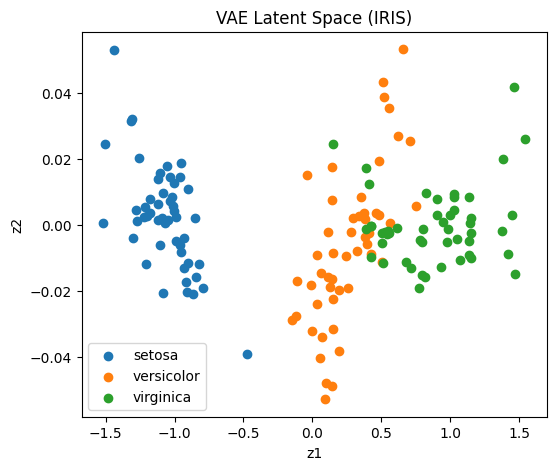

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

for i in range(3):
    plt.scatter(Z[y==i, 0], Z[y==i, 1], label=iris.target_names[i])

plt.xlabel("z1")
plt.ylabel("z2")
plt.legend()
plt.title("VAE Latent Space (IRIS)")
plt.show()